In [5]:
import string
import pandas as pd
import matplotlib.pyplot as plt
import os as os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

from sklearn.model_selection import train_test_split
import random
import pymorphy3
morph = pymorphy3.MorphAnalyzer()
import re
import numpy as np
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
import time
from sklearn.model_selection import GridSearchCV
from collections import Counter
from IPython.display import display
from wordcloud import WordCloud

df = pd.read_excel('E:\MII\laboratory\РАИИ\Практика №1 NLP\Практика №1 NLP\Отзывы 100.xlsx')

data = []

for _, row in df.iterrows():
    text = row[0]
    tone = row[1]
    data.append((text, tone))

result_df = pd.DataFrame(data, columns=["text", "tone"])

result_df = result_df.dropna()

lemm = WordNetLemmatizer()
stem = PorterStemmer()
stop_words = set(stopwords.words('russian'))

X = result_df['text']
y = result_df['tone']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

result_df = result_df.reset_index(drop=True)

def preproc(text):
    if isinstance(text, bytes):
       text = text.decode("utf-8")

    text = re.sub(r'<[^>]+>',' ',text)
    text = re.sub(f'[{string.punctuation}0-9]', ' ', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [morph.parse(word)[0].normal_form for word in tokens]
    return ' '.join(tokens)

sample_text = random.choice(X)
print("==До очистки==")
print(sample_text[:500],"...\n")

cleaned_text = preproc(sample_text)
print("==После очистки==")
print(cleaned_text[:500],"...")

<>:29: SyntaxWarning: invalid escape sequence '\M'
<>:29: SyntaxWarning: invalid escape sequence '\M'
C:\Users\nikbe\AppData\Local\Temp\ipykernel_24768\3198149683.py:29: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_excel('E:\MII\laboratory\РАИИ\Практика №1 NLP\Практика №1 NLP\Отзывы 100.xlsx')
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nikbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


==До очистки==
Хорошая клиника, вежливый персонал. Обращался с диагнозом "варикоцеле". Осмотрели, назначили дату, провели операцию, дали "послеоперационные рекомендации". Всё хорошо, всем доволен. Врач - Кернесюк Мирослав Николаевич.
                         ...

==После очистки==
хороший клиника вежливый персонал обращаться диагноз варикоцель осмотреть назначить дата провести операция дать послеоперационный рекомендация всё весь довольный врач кернесюк мирослав николаевич ...


C:\Users\nikbe\AppData\Local\Temp\ipykernel_24768\3198149683.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  text = row[0]
C:\Users\nikbe\AppData\Local\Temp\ipykernel_24768\3198149683.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tone = row[1]


In [6]:
vectorizers = {
    "TF-IDF": TfidfVectorizer(
        max_features=10000,
        stop_words=stopwords.words('russian'),
        lowercase=True,
        ngram_range=(1,2)
    ),
    "BoW": CountVectorizer(
        max_features=10000,
        stop_words=stopwords.words('russian'),
        binary=True
    )
}

vect_comp_res = {}

for name, vectorizer in vectorizers.items():

    start_time = time.time()

    x_train = vectorizer.fit_transform([preproc(text) for text in X_train])
    x_test = vectorizer.transform([preproc(text) for text in X_test])

    svm_model = SVC(
        kernel = 'linear',
        C=0.2,
        random_state=42,
        probability=True
    )

    svm_model.fit(x_train, y_train)
    y_pred = svm_model.predict(x_test)
    y_proba = svm_model.predict_proba(x_test)[:, 1]

    end_time = time.time()

    vect_comp_res[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc auc": roc_auc_score(y_test, y_proba),
        "time": end_time - start_time
    }

    print(f"Классификация с векторизатором {name} \n")
    print(classification_report(y_test, y_pred))
    print("-" * 100)

Классификация с векторизатором TF-IDF 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20

----------------------------------------------------------------------------------------------------


e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Классификация с векторизатором BoW 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20

----------------------------------------------------------------------------------------------------


e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


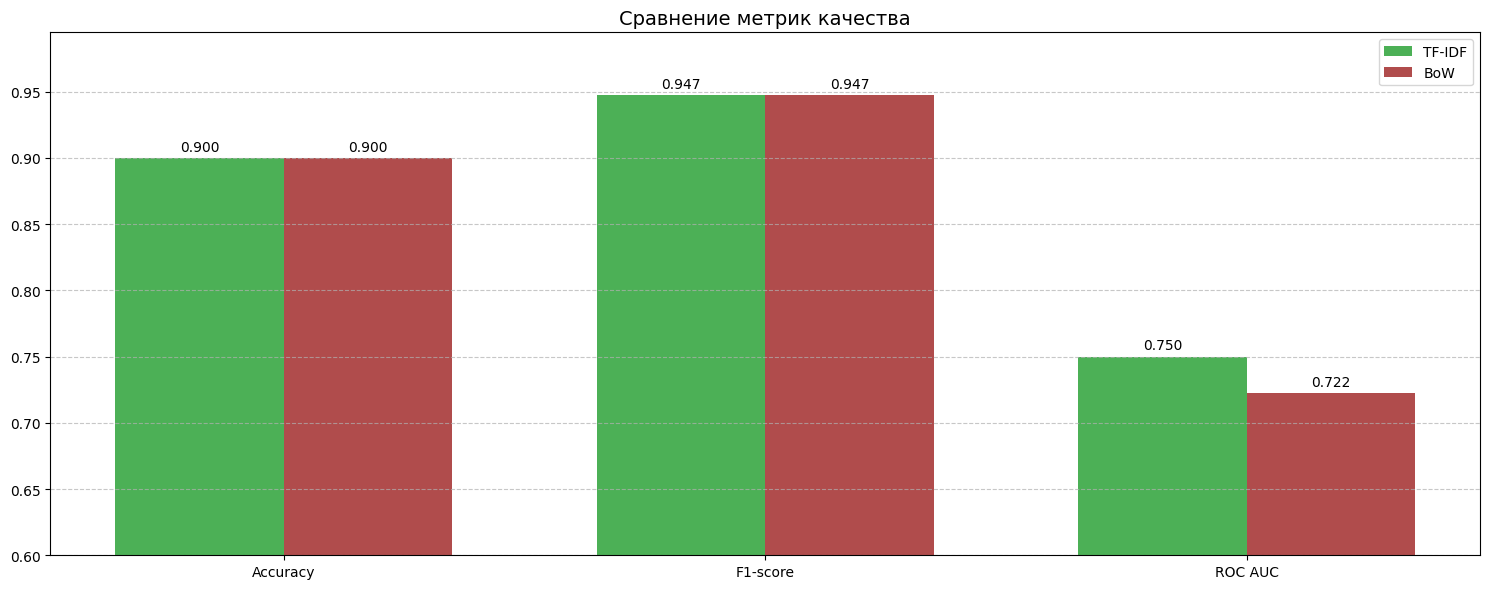

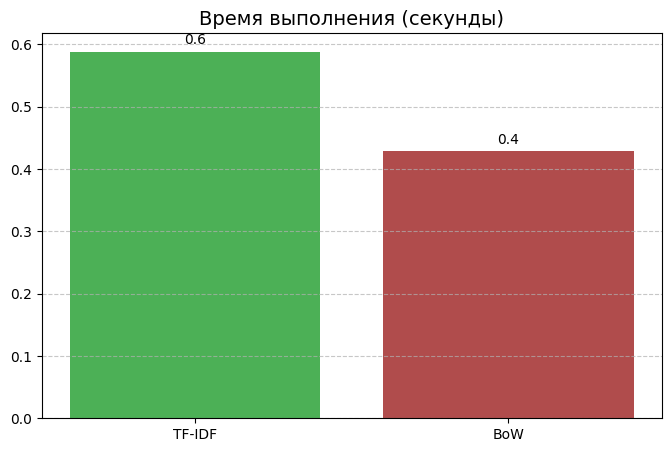

e:\MII\laboratory\mai\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
e:\MII\laboratory\mai\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
9 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "e:\MII\laboratory\mai\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "e:\MII\laboratory\mai\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args,

Лучшие параметры: {'C': 0.1, 'kernel': 'linear'}


In [7]:
colors = ['#4cb056','#b04c4c']
metrics = ['accuracy','f1','roc auc']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(15,6))
bars1 = ax.bar(x - width/2, [vect_comp_res['TF-IDF'][m] for m in metrics],
               width, label='TF-IDF', color=colors[0])
bars2 = ax.bar(x + width/2, [vect_comp_res['BoW'][m] for m in metrics],
               width, label='BoW', color=colors[1])

ax.set_title('Сравнение метрик качества',fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy','F1-score','ROC AUC'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x()+bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center',va='bottom')
plt.ylim(bottom=0.6)
plt.tight_layout()
plt.show()

colors = ['#4cb056','#b04c4c']
fig, ax = plt.subplots(figsize=(8,5))
times = [vect_comp_res['TF-IDF']['time'], vect_comp_res['BoW']['time']]
bars = ax.bar(['TF-IDF','BoW'], times, color=colors)

ax.set_title('Время выполнения (секунды)', fontsize=14)
ax.grid(axis='y',linestyle='--',alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')
plt.show()

X_hyper, _, y_hyper, _ = train_test_split(
    X, y,
    #train_size =0.01,
    train_size =6,
    stratify=y,
    random_state=42
)

vectorizer = TfidfVectorizer(
        max_features=10000,
        stop_words=stopwords.words('russian'),
        lowercase=True,
        ngram_range=(1,2)
)

x_train = vectorizer.fit_transform([preproc(text) for text in X_hyper])

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly']
}

svc = SVC(probability=True)
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_hyper)

print("Лучшие параметры:", grid_search.best_params_)

X_train_cleaned = [preproc(text) for text in X_train]
X_test_cleaned = [preproc(text) for text in X_test]
pos_texts = [text for text, label in zip(X_test_cleaned, y) if label == 1]
neg_texts = [text for text, label in zip(X_test_cleaned, y) if label == 0]

all_text_p = ' '.join(pos_texts)
wordcloud_p = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(all_text_p)

all_text_n = ' '.join(neg_texts)
wordcloud_n = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(all_text_n)

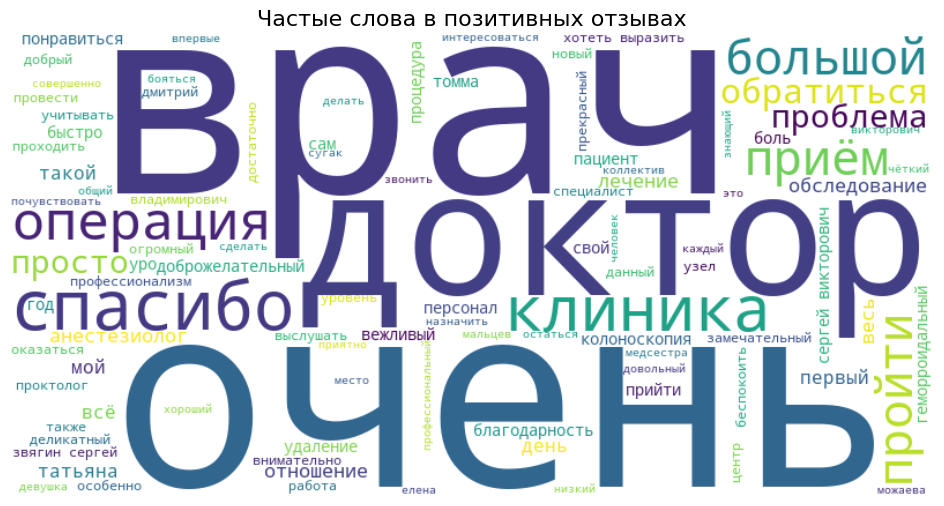

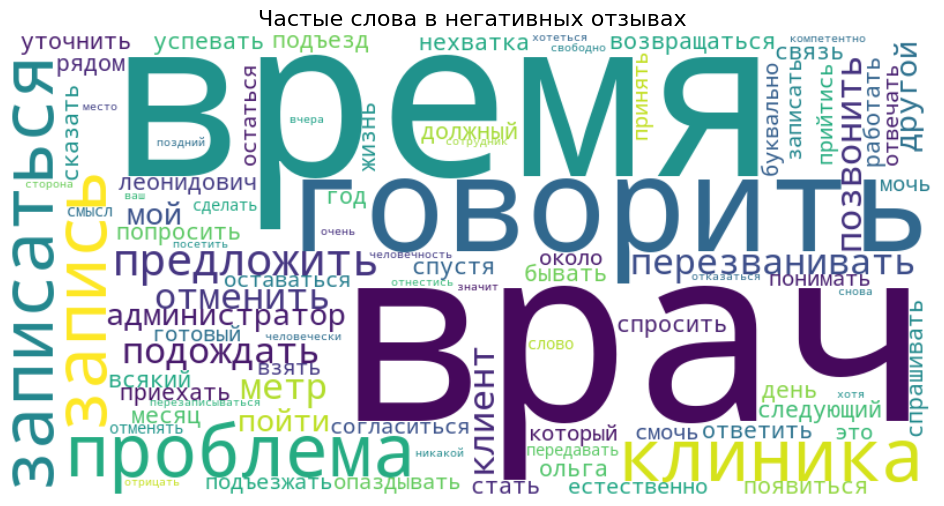

In [8]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_p, interpolation='bilinear')
plt.axis('off')
plt.title('Частые слова в позитивных отзывах', fontsize=16)
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_n, interpolation='bilinear')
plt.axis('off')
plt.title('Частые слова в негативных отзывах', fontsize=16)
plt.show()

In [9]:
pos = []
words_p = all_text_p.split()
word_freq_p = Counter(words_p)
top_words_p = word_freq_p.most_common(20)
for word, freq in top_words_p:
    pos.append(f'{word}: {freq} раз')

neg = []
words_n = all_text_n.split()
word_freq_n = Counter(words_n)
top_words_n = word_freq_n.most_common(20)
for word, freq in top_words_n:
    neg.append(f'{word}: {freq} раз')

data = {
    ('Положительные'): pd.Series(pos),
    ('Негативные'): pd.Series(neg)
}

display(pd.DataFrame(data))

default_stopwords = list(stopwords.words('russian'))
custom_stopwords = {'врач','клиника','очень','операция','доктор','отделение','спасибо'}
all_stopwords = default_stopwords + list(custom_stopwords)

opt_vectorizers = {
    "TF-IDF": TfidfVectorizer(
        max_features=10000,
        stop_words=all_stopwords,
        lowercase=True,
        ngram_range=(1,2)
    ),
    "BoW": CountVectorizer(
        max_features=10000,
        stop_words=all_stopwords,
        binary=True
    )
}

optim_result = {}

for name, vectorizer in opt_vectorizers.items():
    x_train = vectorizer.fit_transform([preproc(text) for text in X_train])
    x_test = vectorizer.transform([preproc(text) for text in X_test])
    svm_model = SVC(
        kernel = 'linear',
        C=1,
        random_state=42,
        probability=True
    )
    svm_model.fit(x_train, y_train)
    y_pred = svm_model.predict(x_test)
    y_proba = svm_model.predict_proba(x_test)[:, 1]

    optim_result[name] = {
        "estimator": svm_model,
        "vectorizer": vectorizer,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_scores": y_proba,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc auc": roc_auc_score(y_test, y_proba)
    }

    print(f"Классификация с оптимизированным векторизатором {name} \n")
    print(classification_report(y_test, y_pred))
    print("-" * 100)

data = {
    ('Base TFIDF', 'Негативные'): [],
    ('Base TFIDF', 'Позитивные'): [],
    ('Optim TFIDF', 'Негативные'): [],
    ('Optim TFIDF', 'Позитивные'): [],
}

df = pd.DataFrame(data)


,Положительные,Негативные
0,врач: 21 раз,врач: 5 раз
1,очень: 20 раз,время: 4 раз
2,доктор: 12 раз,говорить: 4 раз
3,спасибо: 11 раз,проблема: 3 раз
4,клиника: 10 раз,записаться: 3 раз
5,операция: 9 раз,запись: 3 раз
6,приём: 7 раз,клиника: 3 раз
7,пройти: 7 раз,предложить: 3 раз
8,большой: 7 раз,позвонить: 2 раз
9,обратиться: 7 раз,отменить: 2 раз


Классификация с оптимизированным векторизатором TF-IDF 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20

----------------------------------------------------------------------------------------------------


e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Классификация с оптимизированным векторизатором BoW 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20

----------------------------------------------------------------------------------------------------


e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\MII\laboratory\mai\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
for key, items in optim_result.items():
    feature_names = items['vectorizer'].get_feature_names_out()
    coef = items['estimator'].coef_[0]
    abs_coef = np.abs(coef.data)
    top_indices = np.argsort(abs_coef)[::-1][:40]
    neg = []
    pos = []
    for idx in top_indices:
        orig_idx = coef.indices[idx]
        if coef.data[idx] > 0:
            pos.append(f'{feature_names[orig_idx]}: {coef.data[idx]:.4f}')
        else:
            neg.append(f'{feature_names[orig_idx]}: {coef.data[idx]:.4f}')
    df[(key, 'Негативные')] = pd.Series(neg)
    df[(key, 'Позитивные')] = pd.Series(pos)

print('Самые важные слова для классификации:')
display(df)

Самые важные слова для классификации:


Base TFIDF            Optim TFIDF             \
   Негативные Позитивные  Негативные Позитивные   
0         NaN        NaN         NaN        NaN   
1         NaN        NaN         NaN        NaN   
2         NaN        NaN         NaN        NaN   
3         NaN        NaN         NaN        NaN   
4         NaN        NaN         NaN        NaN   
5         NaN        NaN         NaN        NaN   
6         NaN        NaN         NaN        NaN   
7         NaN        NaN         NaN        NaN   
8         NaN        NaN         NaN        NaN   
9         NaN        NaN         NaN        NaN   
10        NaN        NaN         NaN        NaN   
11        NaN        NaN         NaN        NaN   
12        NaN        NaN         NaN        NaN   
13        NaN        NaN         NaN        NaN   
14        NaN        NaN         NaN        NaN   
15        NaN        NaN         NaN        NaN   
16        NaN        NaN         NaN        NaN   
17        NaN        NaN         NaN        NaN   
18        NaN        NaN         NaN        NaN   
19        NaN        NaN         NaN        NaN   
20        NaN        NaN         NaN        NaN   
21        NaN        NaN         NaN        NaN   
22        NaN        NaN         NaN        NaN   
23        NaN        NaN         NaN        NaN   
24        NaN        NaN         NaN        NaN   
25        NaN        NaN         NaN        NaN   
26        NaN        NaN         NaN        NaN   
27        NaN        NaN         NaN        NaN   
28        NaN        NaN         NaN        NaN   
29        NaN        NaN         NaN        NaN   
30        NaN        NaN         NaN        NaN   
31        NaN        NaN         NaN        NaN   
32        NaN        NaN         NaN        NaN   
33        NaN        NaN         NaN        NaN   
34        NaN        NaN         NaN        NaN   
35        NaN        NaN         NaN        NaN   
36        NaN        NaN         NaN        NaN   
37        NaN        NaN         NaN        NaN   
38        NaN        NaN         NaN        NaN   

                                TF-IDF                 \
                            Негативные     Позитивные   
0                        рука: -0.3587  приём: 0.1830   
1                        цена: -0.3048            NaN   
2                         муж: -0.2719            NaN   
3                     считать: -0.2671            NaN   
4                       львов: -0.2671            NaN   
5                      уролог: -0.2663            NaN   
6                      минута: -0.2615            NaN   
7                        итог: -0.2578            NaN   
8                   посчитать: -0.2439            NaN   
9                      деньга: -0.2338            NaN   
10                    человек: -0.2300            NaN   
11                     оплата: -0.2258            NaN   
12                    длиться: -0.2123            NaN   
13                     думать: -0.2105            NaN   
14                     сервис: -0.2099            NaN   
15               регистратура: -0.2056            NaN   
16                        это: -0.2051            NaN   
17                    женщина: -0.2011            NaN   
18                    биопсия: -0.1966            NaN   
19                   возможно: -0.1935            NaN   
20                  последний: -0.1813            NaN   
21              личный беседа: -0.1813            NaN   
22                       боль: -0.1802            NaN   
23  некомпетентность возможно: -0.1802            NaN   
24             оплата лечение: -0.1802            NaN   
25            думать хотеться: -0.1802            NaN   
26         возможно умышленно: -0.1802            NaN   
27               хотеться это: -0.1802            NaN   
28            считать лечение: -0.1802            NaN   
29                     гранью: -0.1802            NaN   
30                 это гранью: -0.1802            NaN   
31                цель оплата: